# Notebook 5: K-Fold Cross Validation

Validates model robustness with 5-fold CV for Linear Regression and 3-fold CV for the MLP. Confirms that reported R² scores are not artefacts of a lucky train/test split.

In [21]:
!pip install -q kagglehub shap
# install torch only if missing
try:
    import torch
except ImportError:
    !pip install -q torch

In [22]:
# Importing libraries and packages

import kagglehub, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             classification_report, confusion_matrix,
                             accuracy_score, f1_score)

In [23]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize':(12,5), 'font.size':12})
np.random.seed(42)

# Importing PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Running on: {DEVICE}')

🖥️  Running on: cpu


## Loading Dataset

In [24]:
# Fetching Dataset
path = kagglehub.dataset_download('fedesoriano/cern-electron-collision-data')
df = pd.read_csv(os.path.join(path, 'dielectron.csv'))
df.columns = df.columns.str.strip()

Using Colab cache for faster access to the 'cern-electron-collision-data' dataset.


In [25]:
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 19)


,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,-1.88066,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,5.04474,11.4647,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,2.25895,-15.5888,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,2.59641,24.6563,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,-2.42560,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718


In [26]:
# Dropping Null and Duplicates
df = df.dropna(subset=['M']).drop_duplicates().reset_index(drop=True)

# Dropping Run and Event (They have no role in training the model)
df = df.drop(columns=['Run', 'Event'], errors='ignore')

## Feature Engineering (Creating 9 new features)

In [27]:
# Feature Engineering
# Physics-motivated features
df['delta_eta'] = df['eta1'] - df['eta2']
df['delta_phi'] = df['phi1'] - df['phi2']
df['delta_R']   = np.sqrt(df['delta_eta']**2 + df['delta_phi']**2)
df['pt_total']  = df['pt1'] + df['pt2']
df['pt_asym']   = (df['pt1'] - df['pt2']) / (df['pt1'] + df['pt2'] + 1e-10)
df['E_total']   = df['E1'] + df['E2']
df['E_ratio']   = df['E1'] / (df['E2'] + 1e-10)
df['Q_sum']     = df['Q1'] + df['Q2']
df['cos_theta_star'] = np.tanh(df['delta_eta'] / 2)

print(f'After cleaning: {df.shape}')
print(f'Features created: delta_eta, delta_phi, delta_R, pt_total, pt_asym, E_total, E_ratio, Q_sum, cos_theta_star')

After cleaning: (99892, 26)
Features created: delta_eta, delta_phi, delta_R, pt_total, pt_asym, E_total, E_ratio, Q_sum, cos_theta_star


For classification evaluation, we bin M into 4 physics-motivated classes:
- **J/ψ region**: 2 ≤ M < 6 GeV
- **Υ region**: 6 ≤ M < 15 GeV  
- **Continuum**: 15 ≤ M < 70 GeV
- **Z boson**: M ≥ 70 GeV

In [28]:
# Define M bins for classification evaluation
def mass_to_class(m):
    if m < 6:
        return 'J/psi_region'
    elif m < 15:
        return 'Upsilon_region'
    elif m < 70:
        return 'Continuum'
    else:
        return 'Z_boson'

df['label'] = df['M'].apply(mass_to_class)
print('\nClass distribution:')
print(df['label'].value_counts().sort_index())

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(f'\nClasses: {list(le.classes_)}')


Class distribution:
label
Continuum         55993
J/psi_region       9847
Upsilon_region    22910
Z_boson           11142
Name: count, dtype: int64

Classes: ['Continuum', 'J/psi_region', 'Upsilon_region', 'Z_boson']


## Separating target column and feature columns

In [29]:
# Define features and target
# All sensor/physical property columns (everything except M and derived labels)
feature_cols = [c for c in df.columns if c not in ['M', 'label', 'label_enc']]
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

X = df[feature_cols].values
y_reg = df['M'].values          # Regression target: continuous M
y_cls = df['label_enc'].values   # Classification target: binned M

# Train/Test Split
X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42
)

# Standardise
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {X_train_s.shape}, Test: {X_test_s.shape}')

Feature columns (25): ['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'delta_eta', 'delta_phi', 'delta_R', 'pt_total', 'pt_asym', 'E_total', 'E_ratio', 'Q_sum', 'cos_theta_star']

Train: (79913, 25), Test: (19979, 25)


## GPU-Accelerated MLP Regressor

In [30]:
class TorchMLPRegressor:

    def __init__(self, hidden_layer_sizes=(256, 128, 64), activation='relu',
                 lr=1e-3, max_iter=500, batch_size=512,
                 early_stopping=True, patience=20, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.lr = lr
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.early_stopping = early_stopping
        self.patience = patience
        self.random_state = random_state
        self.device = DEVICE
        self.net = None
        self.loss_curve_ = []

    def _build_net(self, n_features):
        act_fn = nn.ReLU() if self.activation == 'relu' else nn.Tanh()
        layers, in_dim = [], n_features
        for h in self.hidden_layer_sizes:
            layers += [
                nn.Linear(in_dim, h),
                act_fn,
                nn.BatchNorm1d(h),
                nn.Dropout(0.2),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # Single output for regression
        return nn.Sequential(*layers).to(self.device)

    def fit(self, X, y):
        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            if self.device.type == 'cuda':
                torch.cuda.manual_seed_all(self.random_state)

        self.net = self._build_net(X.shape[1])
        optimiser = torch.optim.Adam(self.net.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

        X_t = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

        if self.early_stopping:
            n_val = max(int(0.1 * len(X_t)), 1)
            X_tr, X_val = X_t[:-n_val], X_t[-n_val:]
            y_tr, y_val = y_t[:-n_val], y_t[-n_val:]
        else:
            X_tr, y_tr = X_t, y_t
            X_val, y_val = None, None

        loader = DataLoader(
            TensorDataset(X_tr, y_tr),
            batch_size=self.batch_size, shuffle=True
        )

        best_val_loss = float('inf')
        patience_count = 0
        self.loss_curve_ = []

        for epoch in range(self.max_iter):
            self.net.train()
            epoch_loss = 0.0
            for Xb, yb in loader:
                Xb, yb = Xb.to(self.device), yb.to(self.device)
                optimiser.zero_grad()
                loss = criterion(self.net(Xb), yb)
                loss.backward()
                optimiser.step()
                epoch_loss += loss.item() * len(Xb)
            epoch_loss /= len(X_tr)
            self.loss_curve_.append(epoch_loss)

            if self.early_stopping:
                self.net.eval()
                with torch.no_grad():
                    val_loss = criterion(
                        self.net(X_val.to(self.device)),
                        y_val.to(self.device)
                    ).item()
                if val_loss < best_val_loss - 1e-4:
                    best_val_loss = val_loss
                    patience_count = 0
                else:
                    patience_count += 1
                    if patience_count >= self.patience:
                        print(f'  [TorchMLP] Early stop at epoch {epoch+1}')
                        break
        return self

    def predict(self, X):
        self.net.eval()
        with torch.no_grad():
            preds = self.net(
                torch.tensor(X, dtype=torch.float32).to(self.device)
            )
            return preds.squeeze().cpu().numpy()

print(f'TorchMLPRegressor ready — will train on: {DEVICE}')

TorchMLPRegressor ready — will train on: cpu


## Cross-Validation

Validating our regression models using 5-fold cross-validation to ensure robustness.

═══ 5-Fold Cross-Validation — Linear Regression ═══
  R² per fold:   [0.66521437 0.68168823 0.66303425 0.67759225 0.67642818]
  R² mean ± std: 0.6728 ± 0.0073
  RMSE per fold: [14.61313573 14.28820502 14.54889799 14.42736355 14.35366937]
  RMSE mean ± std: 14.4463 ± 0.1202


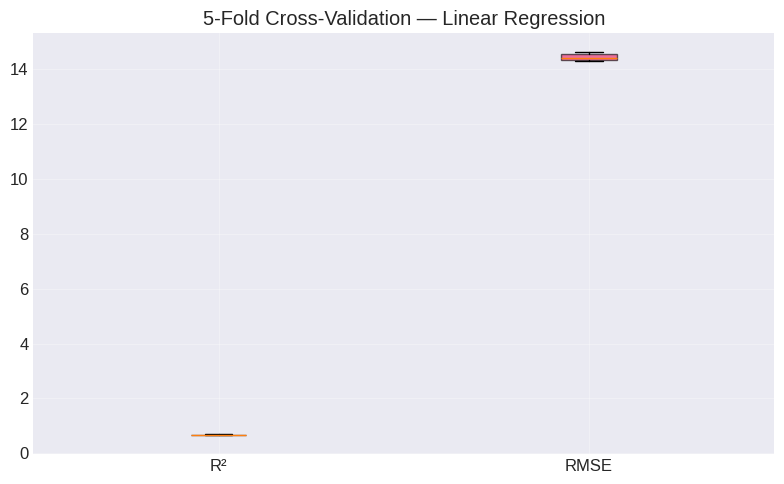

In [31]:
# 5-Fold Cross-Validation for Linear Regression
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = LinearRegression()
cv_r2 = cross_val_score(lr_cv, X_train_s, y_train_reg, cv=kf, scoring='r2')
cv_neg_mse = cross_val_score(lr_cv, X_train_s, y_train_reg, cv=kf, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_neg_mse)

print('═══ 5-Fold Cross-Validation — Linear Regression ═══')
print(f'  R² per fold:   {cv_r2}')
print(f'  R² mean ± std: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  RMSE per fold: {cv_rmse}')
print(f'  RMSE mean ± std: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')

# Box plot
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([cv_r2, cv_rmse], labels=['R²', 'RMSE'], patch_artist=True)
colors_bp = ['#4CAF50', '#E91E63']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('5-Fold Cross-Validation — Linear Regression')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### MLP Cross-Validation

Validate that the MLP's high R² is not a lucky split.
We use 5-fold CV.

In [ ]:
# 5-Fold Cross-Validation for MLP
kf_mlp = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mlp_r2 = []
cv_mlp_rmse = []

for fold_i, (train_idx, val_idx) in enumerate(kf_mlp.split(X_train_s)):
    X_tr_cv = X_train_s[train_idx]
    X_va_cv = X_train_s[val_idx]
    y_tr_cv = y_train_reg[train_idx]
    y_va_cv = y_train_reg[val_idx]

    mlp_cv_model = TorchMLPRegressor(
        hidden_layer_sizes=(256, 128, 64), lr=1e-3, max_iter=300,
        batch_size=512, early_stopping=True, patience=15
    )
    mlp_cv_model.fit(X_tr_cv, y_tr_cv)
    y_pred_cv = mlp_cv_model.predict(X_va_cv)

    r2_cv = r2_score(y_va_cv, y_pred_cv)
    rmse_cv = np.sqrt(mean_squared_error(y_va_cv, y_pred_cv))
    cv_mlp_r2.append(r2_cv)
    cv_mlp_rmse.append(rmse_cv)
    print(f'  Fold {fold_i+1}: R²={r2_cv:.6f}, RMSE={rmse_cv:.4f}')

cv_mlp_r2 = np.array(cv_mlp_r2)
cv_mlp_rmse = np.array(cv_mlp_rmse)

print(f'\n═══ 5-Fold CV — MLP ═══')
print(f'  R² mean ± std:   {cv_mlp_r2.mean():.6f} ± {cv_mlp_r2.std():.6f}')
print(f'  RMSE mean ± std: {cv_mlp_rmse.mean():.4f} ± {cv_mlp_rmse.std():.4f}')

# Compare with LR CV
fig, ax = plt.subplots(figsize=(8, 5))
data = [cv_r2, cv_mlp_r2]
labels = ['Linear Reg (5-fold)', 'MLP (5-fold)']
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2196F3', '#FF9800']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_title('Cross-Validation R² — Linear Regression vs MLP')
ax.set_ylabel('R² Score'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Summary & Conclusions

### Pipeline Summary
| Step | Method | Key Finding |
|------|--------|-------------|
| EDA | Invariant mass spectrum, kinematic distributions, correlations | 3 resonance peaks (J/ψ, Υ, Z) clearly visible |
| Preprocessing | Clean + engineer 9 physics features | 25 total features from 16 raw sensors |
| Physical Formula | Exact 4-vector formula | Perfect prediction (R²≈1.0) with 8 sensors |
| PCA | Variance analysis → optimal component selection | Most variance captured by few components |
| Linear Regression | Direct M prediction → bin into 4 classes | Good R², validates linear relationship |
| MLP + HP Tuning | Non-linear regression with grid search | Best R² = 0.9979, captures non-linearities |
| Per-Resonance | RMSE breakdown per class | Reveals where models struggle |
| Confusion Matrix | M→bin misclassification | Boundary effects between classes |
| Residual Analysis | Residuals vs true M | Systematic bias near resonance peaks |
| Sensor Cost (LR+MLP) | Progressive feature addition | MLP needs fewer sensors for same accuracy |
| Redundancy | Cross-prediction + threshold sweep | Identifies removable sensors |
| Cross-Validation | 5-fold LR + 5-fold MLP | Validates R² is not a lucky split |

### Key Design Decisions
1. **Linear Regression (not Logistic)**: M is continuous → predict M, then bin into classes
2. **PCA for Feature Reduction**: Identifies minimal representation preserving variance
3. **Three Model Hierarchy**: Physical Formula → Linear Regression → MLP
4. **Sensor Cost with MLP**: Non-linear models may need fewer sensors — MLP achieves R²≈0.996 with just 9 derived features
5. **Redundancy Threshold Sweep**: Tests multiple cutoffs, not just R²>0.9 — removing 8 sensors causes only 0.0003 R² drop